## Model cost/watt as function of one feature: time (days)

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rc('figure', figsize=(10, 8))
np.set_printoptions(precision=4, suppress=False)
# please show all columns
pd.set_option("display.max_columns", 60)
import seaborn as sns
sns.set()

In [2]:
# Import sklearn stuff

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, make_scorer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline


In [3]:
# read cleaned data
dfModelAll = pd.read_csv('../local/data/LBNL_openpv_tts_data/ModelAll.csv', index_col='row', dtype={'state':'category'})

In [4]:
dfModelAll.head()

,num_days,size_kw,state,cost_per_watt,scaleSize
row,,,,,
0,0.0,2.2824,CA,10.734315,0
1,21.0,1.8504,CA,11.108701,0
2,26.0,2.3076,CA,8.667013,0
3,84.0,2.3316,CA,13.270286,0
4,111.0,0.9300,CA,14.654839,0


In [5]:
dfModelAll.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 364212 entries, 0 to 364211
Data columns (total 5 columns):
num_days         364212 non-null float64
size_kw          364212 non-null float64
state            364212 non-null category
cost_per_watt    364212 non-null float64
scaleSize        364212 non-null int64
dtypes: category(1), float64(3), int64(1)
memory usage: 14.2 MB


In [6]:
dfModelAll.state.unique()

[CA, OR, AZ, NY, MN, ..., MD, CT, FL, NM, AR]
Length: 19
Categories (19, object): [CA, OR, AZ, NY, ..., CT, FL, NM, AR]

### Can make a reduced model by sampling; or use the whole dataset.

##### Note: pd.Dataframe.sample() will randomize; this is important for grid_search_cv.  It can choose bad sets if the data is sorted.

In [7]:
dfMod = dfModelAll.sample(frac=1.0, random_state=21)

In [8]:
len(dfModelAll), len(dfMod)

(364212, 364212)

### Let seaborn have a shot

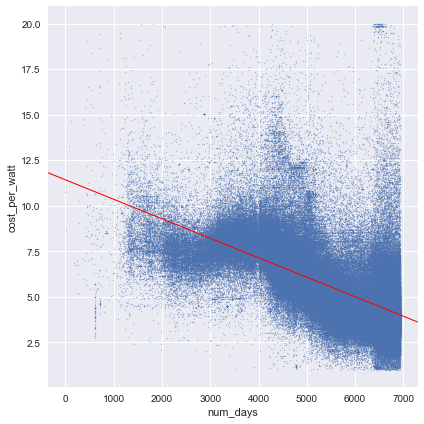

In [9]:
# linear model
sns.lmplot('num_days', 'cost_per_watt', dfMod, 
           size=6, markers='.', 
           scatter_kws={'alpha' : 0.4, 's' : 7},
           line_kws={'color':'red', 'linewidth' : 1});

In [10]:
# # degree 6 polynomial; this takes a while; not recommended unless you go to get some coffee...
# sns.lmplot('num_days', 'cost_per_watt', dfMod, 
#            size=6, markers='.', order=6,
#            scatter_kws={'alpha' : 0.4, 's' : 7},
#            line_kws={'color':'red', 'linewidth' : 1});
# plt.ylim(0.0, 20)

##### Seaborn fits a 6th degree model

![seaborn_6th_fit](./seaborn_6th_fit.png)

#### Set up a sklearn pipeline

In [11]:
# set up to model one feature (column vectors for both X and y)
X = dfMod[['num_days']].values
y = dfMod[['cost_per_watt']].values
X.shape, y.shape

((364212, 1), (364212, 1))

In [12]:
# Setup the pipeline steps
steps = [('scaler', StandardScaler()),
         ('poly', PolynomialFeatures()),
         ('LR', LinearRegression())]

# Create the pipeline: pipeline 
pipeline = Pipeline(steps)

In [13]:
# what's in the pipeline?
pipeline.get_params().keys()

dict_keys(['memory', 'steps', 'scaler', 'poly', 'LR', 'scaler__copy', 'scaler__with_mean', 'scaler__with_std', 'poly__degree', 'poly__include_bias', 'poly__interaction_only', 'LR__copy_X', 'LR__fit_intercept', 'LR__n_jobs', 'LR__normalize'])

In [14]:
# Specify the hyperparameter space.
# Create the hyperparameter grid, just poly degree
poly_space = np.arange(1, 13)
param_grid = {'poly__degree': poly_space}

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=21)

# Create the 3-fold GridSearchCV object: gm_cv
gs_cv = GridSearchCV(pipeline, param_grid, cv=3, return_train_score=True)

# Fit to the training set
gs_cv.fit(X_train, y_train)

# Compute and print the metrics
r2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("test R squared: {}".format(r2))

Best parameters: {'poly__degree': 11}
test R squared: 0.4537458292132197


In [15]:
# this will show the results data structure
gs_cv.cv_results_

{'mean_fit_time': array([0.0536, 0.1103, 0.0784, 0.1444, 0.0956, 0.143 , 0.1337, 0.1735,
        0.1598, 0.1902, 0.1989, 0.235 ]),
 'mean_score_time': array([0.009 , 0.0094, 0.0157, 0.014 , 0.0177, 0.0551, 0.0515, 0.0441,
        0.0431, 0.0541, 0.0518, 0.0575]),
 'mean_test_score': array([0.3998, 0.4073, 0.4238, 0.4362, 0.437 , 0.4458, 0.4459, 0.4465,
        0.4468, 0.4467, 0.4471, 0.447 ]),
 'mean_train_score': array([0.3998, 0.4073, 0.4239, 0.4363, 0.4372, 0.4459, 0.446 , 0.4465,
        0.4469, 0.4469, 0.4471, 0.4471]),
 'param_poly__degree': masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
              mask=[False, False, False, False, False, False, False, False,
                    False, False, False, False],
        fill_value='?',
             dtype=object),
 'params': [{'poly__degree': 1},
  {'poly__degree': 2},
  {'poly__degree': 3},
  {'poly__degree': 4},
  {'poly__degree': 5},
  {'poly__degree': 6},
  {'poly__degree': 7},
  {'poly__degree': 8},
  {'poly__degree

#### The pipeline above is working.  Next step is to add a scorer that produces multiple scores. 

#### instead of defining your own scorer to track multiple metrics, you can hand gridsearchcv a list of scoring fns to use (but you can only use the ones sklearn blesses).  the other way is to pass a dictionary of names and fns.

In [16]:
# we want to search and plot separately

# want to plot both R2 and RMSE
def RMSE(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Create the hyperparameter grid, just poly degree
poly_space = np.arange(1, 21)
param_grid = {'poly__degree': poly_space}

# Create train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=21)

# Create the GridSearchCV object: gs_cv
scoring = {'Rsquared': 'r2',
           'RMSE': make_scorer(RMSE, greater_is_better=False) }

gs_cv = GridSearchCV(pipeline, param_grid, cv=3, 
                     scoring=scoring, return_train_score=True,
                     refit='Rsquared')

# Fit to the training set
gs_cv.fit(X_train, y_train)

# Compute and print the metrics
r2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("test R squared: {}".format(r2))

# uncomment to see results ds
# gs_cv.cv_results_

Best parameters: {'poly__degree': 18}
test R squared: 0.4532136543822757


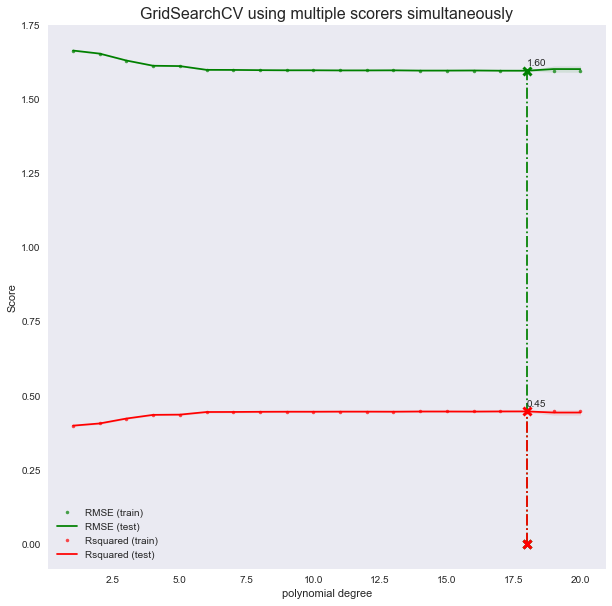

In [17]:
results = gs_cv.cv_results_

fig, ax = plt.subplots(figsize=(10, 10))
plt.title("GridSearchCV using multiple scorers simultaneously", fontsize=16)

plt.xlabel("polynomial degree")
plt.ylabel("Score")

# I think Seaborn ignores this...
plt.grid(True)

###            two__underscores
X_axis = np.array(results['param_poly__degree'].data, dtype=float)

for scorer, color in zip(sorted(scoring), ['g', 'r']):
    for sample, style in (('train', '.'), ('test', '-')):
        sample_score_mean = np.abs(results['mean_%s_%s' % (sample, scorer)])
        sample_score_std = results['std_%s_%s' % (sample, scorer)]
        ax.fill_between(X_axis, sample_score_mean - sample_score_std,
                        sample_score_mean + sample_score_std,
                        alpha=0.1 if sample == 'test' else 0, color=color)
        ax.plot(X_axis, sample_score_mean, style, color=color,
                alpha=1 if sample == 'test' else 0.7,
                label="%s (%s)" % (scorer, sample))

    best_index = np.abs(np.nonzero(results['rank_test_%s' % scorer] == 1)[0][0])
    best_score = np.abs(results['mean_test_%s' % scorer][best_index])

    # Plot a dotted vertical line at the best score for that scorer marked by x
    ax.plot([X_axis[best_index], ] * 2, [0, best_score],
            linestyle='-.', color=color, marker='x', markeredgewidth=3, ms=8)

    # Annotate the best score for that scorer
    ax.annotate("%0.2f" % best_score,
                (X_axis[best_index], best_score + 0.015))

plt.legend(loc="best")
plt.grid(False)
plt.show();

### A little easier to read the metrics

In [18]:
list(zip(gs_cv.cv_results_['param_poly__degree'], 
         gs_cv.cv_results_['mean_test_Rsquared'], 
         np.abs(gs_cv.cv_results_['mean_test_RMSE'])))

[(1, 0.399823680413839, 1.6658452918881124),
 (2, 0.40725014882928795, 1.655504038543092),
 (3, 0.42383536711021413, 1.6321809286726985),
 (4, 0.43621786337546564, 1.6145461091469113),
 (5, 0.4369875097883281, 1.6134438183188788),
 (6, 0.4458462074785508, 1.600697942430186),
 (7, 0.4459989130065513, 1.600477238916332),
 (8, 0.4465537362169004, 1.5996753223043838),
 (9, 0.4468544945408683, 1.5992400084596585),
 (10, 0.4468138906740615, 1.5992984807674688),
 (11, 0.4471355841228676, 1.598834027254531),
 (12, 0.4471167893774178, 1.5988611187775543),
 (13, 0.44691381903805244, 1.599152928146176),
 (14, 0.4475655872077957, 1.5982117423033266),
 (15, 0.44754833694093427, 1.5982368188358318),
 (16, 0.44728998523399954, 1.5986093612955488),
 (17, 0.44781063098973695, 1.5978569820104904),
 (18, 0.4478688896256238, 1.5977731143019254),
 (19, 0.44395741254123544, 1.6033828965916448),
 (20, 0.4440442505628178, 1.6032568476467544)]

### Plot the best model that GridSearchCV finds

Best parameters: {'poly__degree': 18}
Best R squared: 0.4532136543822757


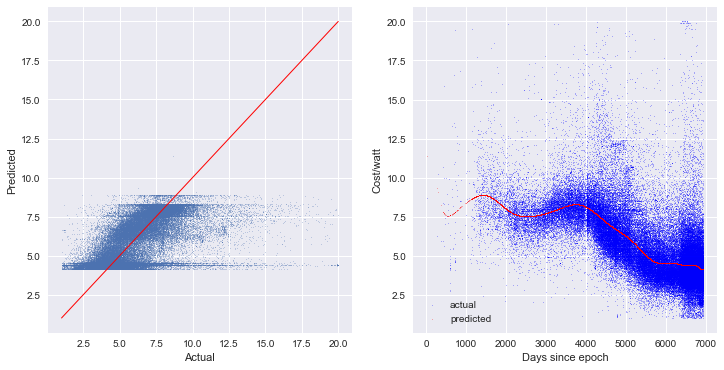

In [19]:
# Show R2
r2 = gs_cv.score(X_test, y_test)
print("Best parameters: {}".format(gs_cv.best_params_))
print("Best R squared: {}".format(r2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.scatter(y_test, gs_cv.predict(X_test), marker='.', s=2, alpha=0.3);
ax1.plot(np.array([1,20]), np.array([1,20]), linewidth=1, color='red')
ax1.set_ylabel('Predicted')
ax1.set_xlabel('Actual')

ax2.scatter(X_test[:, 0], y_test, marker='.', color='blue', s=2, alpha=0.3, label='actual')
ax2.scatter(X_test[:, 0], gs_cv.predict(X_test), marker='.', color='red', s=2, alpha=0.3, label='predicted')
ax2.set_ylabel('Cost/watt')
ax2.set_xlabel('Days since epoch')
ax2.legend()

plt.show();

### Now plot train/test errors vs. complexity


In [23]:
def trainVsTestResults(results):
    
    ''' Plot test/train results for R^2 and RMSE'''
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    sTitle = 'mean train/test RMSE and R^2 vs poly degree'
    fig.suptitle(sTitle)
          
    mean_train_RMSE = results['mean_train_RMSE']
    mean_test_RMSE = results['mean_test_RMSE']
    n = len(mean_train_RMSE)
        
    ax1.plot(np.arange(1, n + 1), np.abs(mean_train_RMSE), marker='d', ms=15, alpha=0.5, color='green', label='train');
    ax1.plot(np.arange(1, n + 1), np.abs(mean_test_RMSE), marker='o', ms=6, alpha=1.0, color='red', label='test');
    ax1.set_ylabel('RMSE')
    ax1.set_xlabel('polynomial degree')
    ax1.set_title('mean train/test RMSE vs poly degree')

    mean_train_R2 = results['mean_train_Rsquared']
    mean_test_R2 = results['mean_test_Rsquared']
    n = len(mean_train_R2)
    
    fig.suptitle(sTitle.format(gs_cv.best_params_))

    ax2.plot(np.arange(1, n + 1), np.abs(mean_train_R2), marker='d', ms=15, alpha=0.5, color='green', label='train');
    ax2.plot(np.arange(1, n + 1), np.abs(mean_test_R2), marker='o', ms=6, color='red', label='test');
    ax2.set_ylabel('R^2')
    ax2.set_xlabel('polynomial degree')
    ax2.set_title('mean train/test R2 vs poly degree')
          
    r2 = gs_cv.score(X_test, y_test)
    print("Best parameters: {}".format(gs_cv.best_params_))
    print("Best R squared: {}".format(r2))

Best parameters: {'poly__degree': 18}
Best R squared: 0.4532136543822757


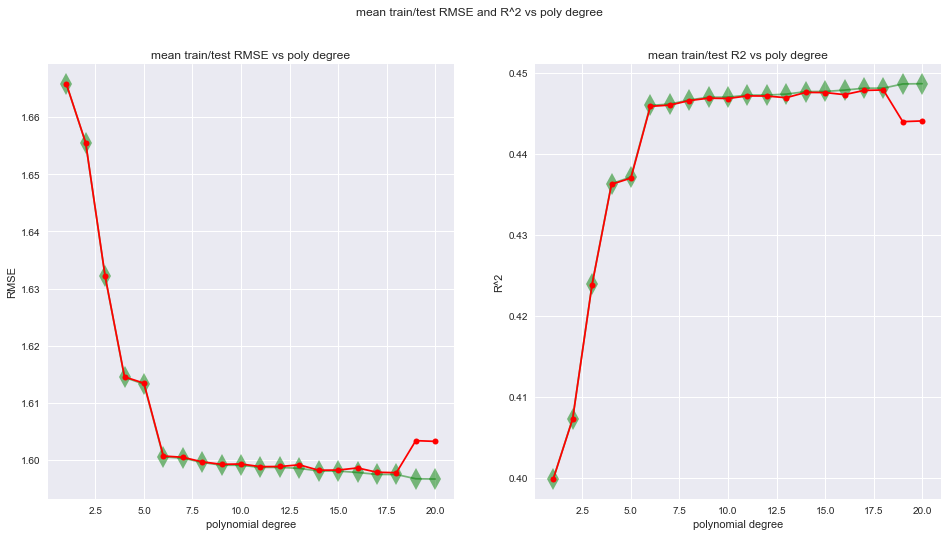

In [24]:
trainVsTestResults(gs_cv.cv_results_)

In [22]:
gs_cv.cv_results_

{'mean_fit_time': array([0.0308, 0.0421, 0.0458, 0.0608, 0.0799, 0.0857, 0.1076, 0.1481,
        0.1671, 0.1678, 0.2042, 0.232 , 0.2527, 0.2757, 0.3466, 0.3108,
        0.3339, 0.3633, 0.4308, 0.4549]),
 'mean_score_time': array([0.006 , 0.013 , 0.0147, 0.0224, 0.0307, 0.0577, 0.0478, 0.0592,
        0.0655, 0.0822, 0.1283, 0.1203, 0.137 , 0.1507, 0.1781, 0.2005,
        0.236 , 0.2413, 0.243 , 0.2824]),
 'mean_test_RMSE': array([-1.6658, -1.6555, -1.6322, -1.6145, -1.6134, -1.6007, -1.6005,
        -1.5997, -1.5992, -1.5993, -1.5988, -1.5989, -1.5992, -1.5982,
        -1.5982, -1.5986, -1.5979, -1.5978, -1.6034, -1.6033]),
 'mean_test_Rsquared': array([0.3998, 0.4073, 0.4238, 0.4362, 0.437 , 0.4458, 0.446 , 0.4466,
        0.4469, 0.4468, 0.4471, 0.4471, 0.4469, 0.4476, 0.4475, 0.4473,
        0.4478, 0.4479, 0.444 , 0.444 ]),
 'mean_train_RMSE': array([-1.6658, -1.6555, -1.6321, -1.6145, -1.6133, -1.6005, -1.6003,
        -1.5996, -1.5991, -1.5991, -1.5987, -1.5987, -1.5985, -1.5981,